In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# Task 1: Data Acquisition & Initial Cleaning
columns = [
    'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8',
    'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16'
]

file_path = '/home/fatih/Documents/Projects/penggalian-data/modul3/datasets/crx.data'
df = pd.read_csv(file_path, header=None, names=columns, na_values='?')

print('First 10 rows:')
display(df.head(10))

print('\nData types per column:')
print(df.dtypes)

print('\nMissing values per column ("?" converted to NaN):')
display(df.isna().sum())

First 10 rows:


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.250,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.040,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.500,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.750,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.710,t,f,0,f,s,120.0,0,+
5,b,32.08,4.000,u,g,m,v,2.500,t,f,0,t,g,360.0,0,+
6,b,33.17,1.040,u,g,r,h,6.500,t,f,0,t,g,164.0,31285,+
7,a,22.92,11.585,u,g,cc,v,0.040,t,f,0,f,g,80.0,1349,+
8,b,54.42,0.500,y,p,k,h,3.960,t,f,0,f,g,180.0,314,+
9,b,42.50,4.915,y,p,w,v,3.165,t,f,0,t,g,52.0,1442,+



Data types per column:
A1         str
A2     float64
A3     float64
A4         str
A5         str
A6         str
A7         str
A8     float64
A9         str
A10        str
A11      int64
A12        str
A13        str
A14    float64
A15      int64
A16        str
dtype: object

Missing values per column ("?" converted to NaN):


A1     12
A2     12
A3      0
A4      6
A5      6
A6      9
A7      9
A8      0
A9      0
A10     0
A11     0
A12     0
A13     0
A14    13
A15     0
A16     0
dtype: int64

In [10]:
# Task 2: Advanced Imputation
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print('\nNumerical columns:', numerical_cols)
print('Categorical columns:', categorical_cols)

# Fill missing values: median for numerical, mode for categorical
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    mode_val = df[col].mode(dropna=True)
    if not mode_val.empty:
        df[col] = df[col].fillna(mode_val.iloc[0])

print('\nMissing values after imputation:')
display(df.isna().sum())



Numerical columns: ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
Categorical columns: ['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13', 'A16']

Missing values after imputation:


A1     0
A2     0
A3     0
A4     0
A5     0
A6     0
A7     0
A8     0
A9     0
A10    0
A11    0
A12    0
A13    0
A14    0
A15    0
A16    0
dtype: int64

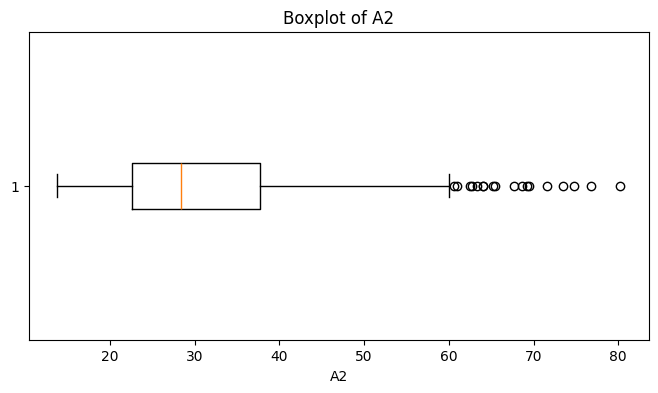

Outliers detected in A2 (IQR method): 18
Outliers exist in column A2.


In [11]:
# Task 3: Outlier Handling (use continuous numerical column A2)
plt.figure(figsize=(8, 4))
plt.boxplot(df['A2'], vert=False)
plt.title('Boxplot of A2')
plt.xlabel('A2')
plt.show()

q1 = df['A2'].quantile(0.25)
q3 = df['A2'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outlier_count = ((df['A2'] < lower_bound) | (df['A2'] > upper_bound)).sum()

print(f'Outliers detected in A2 (IQR method): {outlier_count}')
if outlier_count > 0:
    print('Outliers exist in column A2.')
else:
    print('No outliers detected in column A2.')


In [12]:
# Task 4: Categorical Encoding (One-Hot Encoding for nominal column A1)
df = pd.get_dummies(df, columns=['A1'], prefix='A1', dtype=int)
print('\nApplied One-Hot Encoding on column A1.')


Applied One-Hot Encoding on column A1.


In [13]:
# Task 5: Min-Max Normalization for all numerical columns
# Encode any remaining categorical columns so final dataframe is fully numeric
remaining_categorical = df.select_dtypes(exclude=[np.number]).columns.tolist()
if remaining_categorical:
    df = pd.get_dummies(df, columns=remaining_categorical, drop_first=False, dtype=int)

num_cols_after_encoding = df.select_dtypes(include=[np.number]).columns

for col in num_cols_after_encoding:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max != col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0

print('\nFinal min values:')
display(df[num_cols_after_encoding].min())

print('Final max values:')
display(df[num_cols_after_encoding].max())

print('\nFinal data preview:')
display(df.head())


Final min values:


A2       0.0
A3       0.0
A8       0.0
A11      0.0
A14      0.0
A15      0.0
A1_a     0.0
A1_b     0.0
A4_l     0.0
A4_u     0.0
A4_y     0.0
A5_g     0.0
A5_gg    0.0
A5_p     0.0
A6_aa    0.0
A6_c     0.0
A6_cc    0.0
A6_d     0.0
A6_e     0.0
A6_ff    0.0
A6_i     0.0
A6_j     0.0
A6_k     0.0
A6_m     0.0
A6_q     0.0
A6_r     0.0
A6_w     0.0
A6_x     0.0
A7_bb    0.0
A7_dd    0.0
A7_ff    0.0
A7_h     0.0
A7_j     0.0
A7_n     0.0
A7_o     0.0
A7_v     0.0
A7_z     0.0
A9_f     0.0
A9_t     0.0
A10_f    0.0
A10_t    0.0
A12_f    0.0
A12_t    0.0
A13_g    0.0
A13_p    0.0
A13_s    0.0
A16_+    0.0
A16_-    0.0
dtype: float64

Final max values:


A2       1.0
A3       1.0
A8       1.0
A11      1.0
A14      1.0
A15      1.0
A1_a     1.0
A1_b     1.0
A4_l     1.0
A4_u     1.0
A4_y     1.0
A5_g     1.0
A5_gg    1.0
A5_p     1.0
A6_aa    1.0
A6_c     1.0
A6_cc    1.0
A6_d     1.0
A6_e     1.0
A6_ff    1.0
A6_i     1.0
A6_j     1.0
A6_k     1.0
A6_m     1.0
A6_q     1.0
A6_r     1.0
A6_w     1.0
A6_x     1.0
A7_bb    1.0
A7_dd    1.0
A7_ff    1.0
A7_h     1.0
A7_j     1.0
A7_n     1.0
A7_o     1.0
A7_v     1.0
A7_z     1.0
A9_f     1.0
A9_t     1.0
A10_f    1.0
A10_t    1.0
A12_f    1.0
A12_t    1.0
A13_g    1.0
A13_p    1.0
A13_s    1.0
A16_+    1.0
A16_-    1.0
dtype: float64


Final data preview:


,A2,A3,A8,A11,A14,A15,A1_a,A1_b,A4_l,A4_u,...,A9_t,A10_f,A10_t,A12_f,A12_t,A13_g,A13_p,A13_s,A16_+,A16_-
0,0.256842,0.000000,0.043860,0.014925,0.1010,0.00000,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.675489,0.159286,0.106667,0.089552,0.0215,0.00560,1.0,0.0,0.0,1.0,...,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.161654,0.017857,0.052632,0.000000,0.1400,0.00824,1.0,0.0,0.0,1.0,...,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
3,0.211729,0.055000,0.131579,0.074627,0.0500,0.00003,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
4,0.096541,0.200893,0.060000,0.000000,0.0600,0.00000,0.0,1.0,0.0,1.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0


In [14]:
# Final Submission Check
print('--- Data Info ---')
print(df.info())

print('\n--- Missing Values ---')
print(df.isna().sum().sum())

numeric_check = all(pd.api.types.is_numeric_dtype(dtype) for dtype in df.dtypes)
range_check = ((df.select_dtypes(include=[np.number]) >= 0) & (df.select_dtypes(include=[np.number]) <= 1)).all().all()

print('\n--- Validation ---')
print(f'All columns numeric: {numeric_check}')
print(f'All values in [0, 1]: {range_check}')

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 48 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A2      690 non-null    float64
 1   A3      690 non-null    float64
 2   A8      690 non-null    float64
 3   A11     690 non-null    float64
 4   A14     690 non-null    float64
 5   A15     690 non-null    float64
 6   A1_a    690 non-null    float64
 7   A1_b    690 non-null    float64
 8   A4_l    690 non-null    float64
 9   A4_u    690 non-null    float64
 10  A4_y    690 non-null    float64
 11  A5_g    690 non-null    float64
 12  A5_gg   690 non-null    float64
 13  A5_p    690 non-null    float64
 14  A6_aa   690 non-null    float64
 15  A6_c    690 non-null    float64
 16  A6_cc   690 non-null    float64
 17  A6_d    690 non-null    float64
 18  A6_e    690 non-null    float64
 19  A6_ff   690 non-null    float64
 20  A6_i    690 non-null    float64
 21  A6_j    690 non-null    float64
